# Download packages


In [2]:
!pip install --upgrade pip
!pip install numpy scipy pandas scikit-learn matplotlib ipykernel psutil tensorflow torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 20.7 MB/s  0:00:00


### Fetching Data from the altered data we received


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Split Datasets


In [ ]:
import os
import re
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

class TumorDataset(Dataset):
    def __init__(self, root_dir):
        # fetch all the files in the directory 
        self.root_dir = root_dir
        self.cases = [
           f for f in os.listdir(root_dir)
           if os.path.isdir(os.path.join(root_dir, f))
        ]

        # change all the images in the directory to a 96 x 96 image
        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((96, 96)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.cases)

    # x = images in files not the label and y = label stating how many tumor cells there are
    def __getitem__(self, idx):
        # case_folder = root/case[idx], files = files in case[idx]
        case_folder = os.path.join(self.root_dir, self.cases[idx])
        files = os.listdir(case_folder)

        images = []
        label = None

        
        for f in files:
            path = os.path.join(case_folder, f)

            if "tumor_seg" in f:
                label = int(re.findall(r'\d+', f)[0])
            else:
                img = Image.open(path)
                img = self.transform(img)
                images.append(img)

        x = torch.cat(images, dim=0)
        y = torch.tensor(label, dtype=torch.float32)

        return x, y

Copy zip file of data from the drive to the local colab system

In [1]:
!cp "/content/drive/MyDrive/cases.zip" /content/
!unzip -q /content/cases.zip -d /content/cases

Test/Train split

In [5]:
from torch.utils.data import random_split

dataset = TumorDataset('/content/cases/cases')

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

Neural network model
- Change #1: Network was made simpler to avoid overfitting

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TumorNet(nn.Module):
    def __init__(self):
        super(TumorNet, self).__init__()

        # Smaller CNN
        self.conv1 = nn.Conv2d(4, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # Global average pooling drastically reduces parameters
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Tiny fully connected layer
        self.fc = nn.Linear(16, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # (4,96,96) -> (8,48,48)
        x = self.pool(F.relu(self.conv2(x)))   # -> (16,24,24)

        x = self.gap(x)                        # -> (16,1,1)
        x = x.view(x.size(0), -1)              # -> (16)

        x = self.fc(x)

        return x

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [8]:
x, y = next(iter(train_loader))

print(x.shape)  # expected: (batch, 4, 96, 96)
print(y.shape)  # expected: (batch,)
print(y[:5])

torch.Size([8, 4, 96, 96])
torch.Size([8])
tensor([  0., 129.,   0.,   0.,   0.])


Use GPU if possible and cpu otherwise

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TumorNet().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [10]:
def train(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).float()

        preds = model(images).squeeze()
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [11]:
def test(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).float()

            preds = model(images).squeeze()
            loss = criterion(preds, labels)

            total_loss += loss.item()

    return total_loss / len(loader)

## Training set up and Hyper parameter tuning
- Change #1: Save the Training and Testing data to prevent training and testing data mixup after session ends

Using device: cuda
GPU: Tesla T4
GPU memory allocated: 0.03 GB
GPU memory reserved: 0.06 GB
Loaded previous losses
Loaded previous model
Epoch 321: Train 123.3248, Test 2901.0966
Epoch 322: Train 97.0415, Test 3019.8699
Epoch 323: Train 64.9245, Test 2944.6644
Epoch 324: Train 44.2301, Test 3184.8648
Epoch 325: Train 43.3191, Test 2958.9576
Epoch 326: Train 36.3374, Test 3049.1388
Epoch 327: Train 25.8003, Test 2995.1346
Epoch 328: Train 27.3094, Test 3152.5324
Epoch 329: Train 37.8007, Test 2994.3376
Epoch 330: Train 45.0782, Test 3077.6167
Epoch 331: Train 51.0080, Test 3087.9445
Epoch 332: Train 65.1933, Test 2975.6715
Epoch 333: Train 84.9742, Test 3095.2672
Epoch 334: Train 73.3878, Test 3194.2052
Epoch 335: Train 96.2150, Test 3279.2644
Epoch 336: Train 140.1364, Test 3051.3554
Epoch 337: Train 125.5850, Test 3231.9026
Epoch 338: Train 91.3723, Test 3037.2871
Epoch 339: Train 107.5398, Test 3052.5219
Epoch 340: Train 110.3832, Test 3372.2733
Epoch 341: Train 154.6006, Test 3076.1

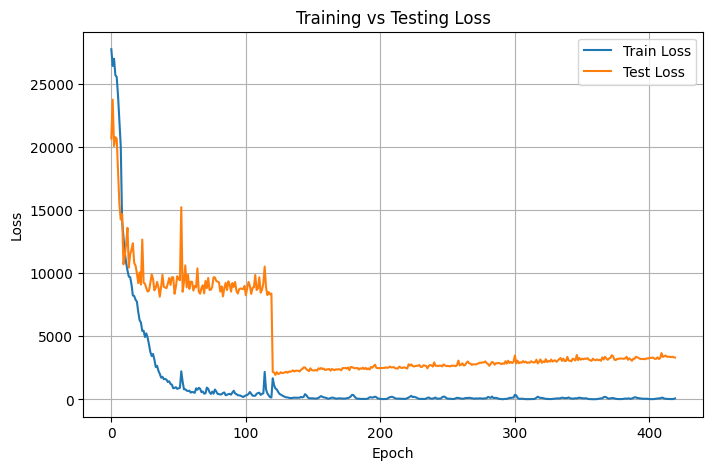

GPU memory allocated: 0.03 GB
GPU memory reserved: 0.06 GB


In [ ]:
import os
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ===== GPU SETUP =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# move model to GPU
model = model.to(device)

# enable cudnn auto-tuner for faster CNN training
torch.backends.cudnn.benchmark = True

if torch.cuda.is_available():

    print(
        "GPU memory allocated:",
        round(torch.cuda.memory_allocated() / 1024**3, 2),
        "GB"
    )

    print(
        "GPU memory reserved:",
        round(torch.cuda.memory_reserved() / 1024**3, 2),
        "GB"
    )

# ===== TRACKING =====
train_losses = []
test_losses = []

# ===== SAVE PATHS =====
save_dir = "/content/drive/MyDrive/tumor_training2"
os.makedirs(save_dir, exist_ok=True)

csv_path = os.path.join(save_dir, "losses.csv")
latest_model_path = os.path.join(save_dir, "latest_model2.pth")
best_model_path = os.path.join(save_dir, "best_model2.pth")

# ==== save datasets ===== 
train_data_path = os.path.join(save_dir, "train_dataset.pt")
test_data_path = os.path.join(save_dir, "test_dataset.pt")

plot_path = os.path.join(save_dir, "loss_plot.png")

# ===== SAVE TRAIN / TEST DATA =====
# saves the exact datasets used by the dataloaders

if not os.path.exists(train_data_path):
    torch.save(train_loader.dataset, train_data_path)
    print("Saved train dataset")

if not os.path.exists(test_data_path):
    torch.save(test_loader.dataset, test_data_path)
    print("Saved test dataset")

# ===== LOAD OLD LOSSES =====
if os.path.exists(csv_path):

    old_df = pd.read_csv(csv_path)

    train_losses = old_df["train_loss"].tolist()
    test_losses = old_df["test_loss"].tolist()

    print("Loaded previous losses")

# ===== LOAD MODEL =====
if os.path.exists(latest_model_path):

    model.load_state_dict(
        torch.load(latest_model_path, map_location=device)
    )

    print("Loaded previous model")

# ===== BEST LOSS TRACKING =====
best_test_loss = float("inf")

if len(test_losses) > 0:
    best_test_loss = min(test_losses)

# ===== TRAINING SETTINGS =====
epochs = 100

# ===== TRAINING LOOP =====
for _ in range(epochs):

    current_epoch = len(train_losses) + 1

    start_time = time.time()

    train_loss = train(model, train_loader)
    test_loss = test(model, test_loader)

    epoch_time = time.time() - start_time

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(
        f"Epoch {current_epoch}: "
        f"Train {train_loss:.4f}, "
        f"Test {test_loss:.4f}, "
        f"Time {epoch_time:.1f}s"
    )

    # ===== SAVE LATEST MODEL =====
    torch.save(model.state_dict(), latest_model_path)

    # ===== SAVE BEST MODEL =====
    if test_loss < best_test_loss:

        best_test_loss = test_loss

        torch.save(model.state_dict(), best_model_path)

        print("Saved new best model")

    # ===== SAVE LOSSES AFTER EVERY EPOCH =====
    loss_df = pd.DataFrame({
        "epoch": list(range(1, len(train_losses) + 1)),
        "train_loss": train_losses,
        "test_loss": test_losses
    })

    loss_df.to_csv(csv_path, index=False)

# ===== FINAL SAVE =====
torch.save(model.state_dict(), latest_model_path)

# ===== FINAL CSV SAVE =====
loss_df = pd.DataFrame({
    "epoch": list(range(1, len(train_losses) + 1)),
    "train_loss": train_losses,
    "test_loss": test_losses
})

loss_df.to_csv(csv_path, index=False)

print("Saved losses CSV")

# ===== PLOT =====
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss")

plt.legend()
plt.grid(True)

plt.savefig(plot_path)

print("Saved plot:", plot_path)

plt.show()

# ===== GPU MEMORY INFO =====
if torch.cuda.is_available():

    print(
        "GPU memory allocated:",
        round(torch.cuda.memory_allocated() / 1024**3, 2),
        "GB"
    )

    print(
        "GPU memory reserved:",
        round(torch.cuda.memory_reserved() / 1024**3, 2),
        "GB"
    )